### 1. Import Library

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

### 2. Load Data Preprocessing

In [2]:
X_train = pd.read_csv('../data/processed/train_scaled.csv')
X_test  = pd.read_csv('../data/processed/test_scaled.csv')
scaler  = joblib.load('../models/scaler.pkl')

FEATURE_COLS = [
    'Usage_kWh',
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor',
    'NSM', 'hour', 'month', 'is_weekend'
]

X_train_feat = X_train[FEATURE_COLS]
X_test_feat  = X_test[FEATURE_COLS]

print('Train:', X_train_feat.shape)
print('Test :', X_test_feat.shape)

Train: (28032, 10)
Test : (7008, 10)


### 3. Elbow Method

c:\Users\Nicolaus Prima\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Nicolaus Prima\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Nicolaus Prima\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Nicolaus Prima\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, e

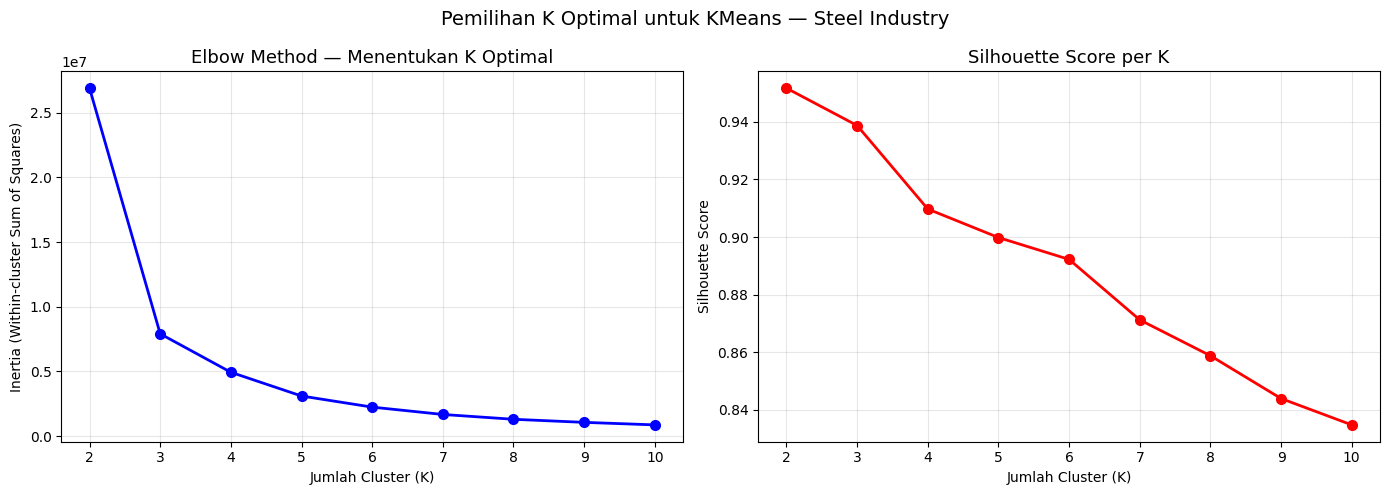

Silhouette Score per K:
  K=2: 0.9517
  K=3: 0.9388
  K=4: 0.9097
  K=5: 0.8998
  K=6: 0.8922
  K=7: 0.8712
  K=8: 0.8587
  K=9: 0.8439
  K=10: 0.8347


In [3]:
inertias   = []
sil_scores = []
K_range    = range(2, 11)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_feat)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_feat, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Menentukan K Optimal', fontsize=13)
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(K_range), sil_scores, 'ro-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score per K', fontsize=13)
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3)

plt.suptitle('Pemilihan K Optimal untuk KMeans — Steel Industry', fontsize=14)
plt.tight_layout()
plt.show()

print('Silhouette Score per K:')
for k, s in zip(K_range, sil_scores):
    print(f'  K={k}: {s:.4f}')

### 4. Clustering

In [4]:
K = 3  # Sesuaikan berdasarkan hasil elbow + silhouette di atas

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)

# fit + predict train
train_labels = kmeans.fit_predict(X_train_feat)

# predict test — TANPA fit ulang
test_labels  = kmeans.predict(X_test_feat)

print('Distribusi cluster — Train:')
unique, counts = np.unique(train_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} record ({c/len(train_labels)*100:.1f}%)')

print()
print('Distribusi cluster — Test:')
unique, counts = np.unique(test_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} record ({c/len(test_labels)*100:.1f}%)')

Distribusi cluster — Train:
  Cluster 0: 22204 record (79.2%)
  Cluster 1: 4904 record (17.5%)
  Cluster 2: 924 record (3.3%)

Distribusi cluster — Test:
  Cluster 0: 5469 record (78.0%)
  Cluster 1: 1407 record (20.1%)
  Cluster 2: 132 record (1.9%)


### 5. Evaluate Clustering

In [5]:
sil_train = silhouette_score(X_train_feat, train_labels)
sil_test  = silhouette_score(X_test_feat,  test_labels)

print(f'Silhouette Score — Train : {sil_train:.4f}')
print(f'Silhouette Score — Test  : {sil_test:.4f}')
print()
if sil_train > 0.5:
    print('Interpretasi: Cluster terbentuk dengan baik (> 0.5)')
elif sil_train > 0.25:
    print('Interpretasi: Cluster cukup baik (0.25 - 0.5)')
else:
    print('Interpretasi: Cluster lemah, pertimbangkan nilai K yang berbeda')

Silhouette Score — Train : 0.9388
Silhouette Score — Test  : 0.9396

Interpretasi: Cluster terbentuk dengan baik (> 0.5)


### 6. Profil Setiap Cluster

Profil rata-rata per cluster (sudah scaled):
         Usage_kWh  Lagging_Current_Reactive.Power_kVarh  Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  Lagging_Current_Power_Factor  Leading_Current_Power_Factor    NSM   hour  month  is_weekend
Cluster                                                                                                                                                                                               
0            0.427                                 0.329                                 0.118      0.737                        -0.353                        -1.141 -0.103 -0.106  0.057       0.211
1           -0.056                                -0.953                                 2.607      0.000                         0.315                      -436.337  0.435  0.449  0.106       0.559
2            0.021                                -0.854                                 1.936      0.072                         0.299                      -2

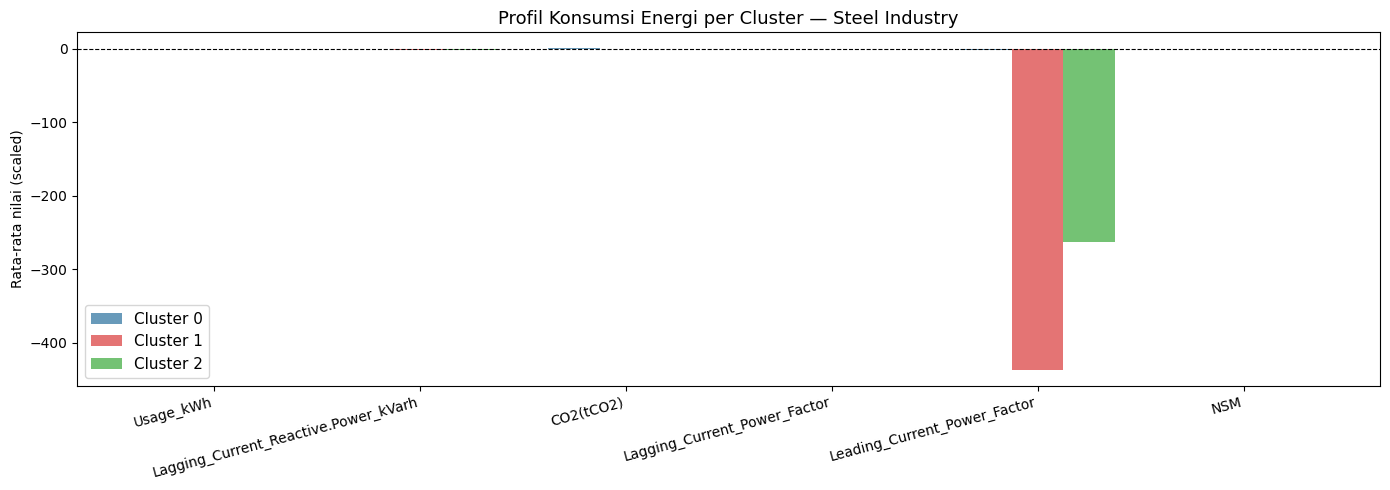

In [6]:
train_with_cluster = X_train_feat.copy()
train_with_cluster['Cluster'] = train_labels

cluster_profile = train_with_cluster.groupby('Cluster')[FEATURE_COLS].mean()

print('Profil rata-rata per cluster (sudah scaled):')
print(cluster_profile.round(3).to_string())

# Visualisasi profil cluster — fokus fitur utama
MAIN_COLS = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
             'CO2(tCO2)', 'Lagging_Current_Power_Factor',
             'Leading_Current_Power_Factor', 'NSM']

fig, ax = plt.subplots(figsize=(14, 5))

x      = np.arange(len(MAIN_COLS))
width  = 0.25
colors = ['#4e89ae', '#e05c5c', '#5cb85c']

for i, cluster_id in enumerate(cluster_profile.index):
    ax.bar(x + i*width, cluster_profile.loc[cluster_id, MAIN_COLS],
           width, label=f'Cluster {cluster_id}', color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(MAIN_COLS, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Rata-rata nilai (scaled)')
ax.set_title('Profil Konsumsi Energi per Cluster — Steel Industry', fontsize=13)
ax.legend(fontsize=11)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

### 7. Interpretasi Cluster

In [7]:
# Sesuaikan nama cluster berdasarkan profil di step 6
# Contoh penamaan berdasarkan pola konsumsi energi:
#   - Cluster dengan Usage_kWh tinggi + NSM tinggi  → 'High Load - Day Shift'
#   - Cluster dengan Usage_kWh rendah               → 'Low Load - Idle'
#   - Cluster dengan Usage_kWh sedang               → 'Medium Load - Night Shift'

cluster_names = {
    0: 'Low Load - Idle',
    1: 'Medium Load - Night Shift',
    2: 'High Load - Day Shift'
}

print('Nama cluster:')
for k, v in cluster_names.items():
    n_record = (train_labels == k).sum()
    print(f'  Cluster {k} : {v} ({n_record} record)')

print()
print('Catatan: Sesuaikan nama cluster di atas berdasarkan')
print('profil konsumsi yang muncul di step 6.')

Nama cluster:
  Cluster 0 : Low Load - Idle (22204 record)
  Cluster 1 : Medium Load - Night Shift (4904 record)
  Cluster 2 : High Load - Day Shift (924 record)

Catatan: Sesuaikan nama cluster di atas berdasarkan
profil konsumsi yang muncul di step 6.


### 8. Content Based Filtering

In [8]:
# ─────────────────────────────────────────────
# 8a. Tentukan Ideal Profile
#     Ideal = cluster dengan Usage_kWh MEDIAN terendah
#             (proxy: paling efisien secara energi)
#
#     PENTING — gunakan MEDIAN, bukan mean:
#     Fitur Leading_Current_Power_Factor memiliki IQR sangat kecil
#     (~0.23) setelah RobustScaler karena ~90% data raw = 100.0.
#     Akibatnya, nilai mean cluster bisa anomali (mis. -436.337).
#     Median memberikan nilai yang jauh lebih representatif.
# ─────────────────────────────────────────────

ideal_cluster_id = int(cluster_profile['Usage_kWh'].idxmin())

# Median per cluster — robust terhadap outlier ekstrem
cluster_median = train_with_cluster.groupby('Cluster')[FEATURE_COLS].median()
ideal_profile  = cluster_median.loc[ideal_cluster_id]

print(f'Ideal profile → Cluster {ideal_cluster_id} ({cluster_names[ideal_cluster_id]})')
print()
print('--- Perbandingan Mean vs Median untuk cluster ideal ---')
print('(Perhatikan perbedaan drastis pada Leading_Current_Power_Factor)')
comparison_df = pd.DataFrame({
    'Mean (sebelumnya)': cluster_profile.loc[ideal_cluster_id].round(3),
    'Median (digunakan)': cluster_median.loc[ideal_cluster_id].round(3)
})
print(comparison_df)
print()
print('Ideal profile yang digunakan (median):')
print(ideal_profile.round(3))


Ideal profile → Cluster 1 (Medium Load - Night Shift)

--- Perbandingan Mean vs Median untuk cluster ideal ---
(Perhatikan perbedaan drastis pada Leading_Current_Power_Factor)
                                      Mean (sebelumnya)  Median (digunakan)
Usage_kWh                                        -0.056              -0.075
Lagging_Current_Reactive.Power_kVarh             -0.953              -0.970
Leading_Current_Reactive_Power_kVarh              2.607               2.578
CO2(tCO2)                                         0.000               0.000
Lagging_Current_Power_Factor                      0.315               0.321
Leading_Current_Power_Factor                   -436.337            -443.833
NSM                                               0.435               0.495
hour                                              0.449               0.478
month                                             0.106               0.200
is_weekend                                        0.559         

In [9]:
# ─────────────────────────────────────────────
# Definisi rule rekomendasi berbasis fitur
#
# Setiap rule berisi:
#   - condition : fungsi yang menerima nilai fitur aktual
#                 dan nilai ideal, return True jika perlu rekomendasi
#   - message   : template rekomendasi (f-string)
#   - priority  : 1=urgent, 2=sedang, 3=info
#
# Perubahan threshold vs versi sebelumnya:
#   Lagging_Current_Power_Factor    : 0.1  → 0.3  (kurangi over-trigger)
#   Leading_Current_Power_Factor    : relatif ideal → absolut -50
#     Alasan: IQR fitur ini ~0.23 sehingga threshold relatif tidak stabil.
#     -50 ≈ raw PF < ~88% (di mana nilai normal mendekati 100%)
#   Lagging_Current_Reactive_Power  : 0.2  → 0.5  (kurangi over-trigger)
#   Leading_Current_Reactive_Power  : 0.2  → 0.5  (kurangi over-trigger)
# ─────────────────────────────────────────────

RULES = [
    {
        'feature'  : 'Lagging_Current_Power_Factor',
        'condition': lambda actual, ideal: actual < ideal - 0.3,
        'message'  : lambda actual, ideal: (
            f'Lagging PF = {actual:.3f}, di bawah profil efisien ({ideal:.3f}). '
            f'Gap = {ideal - actual:.3f} — pasang capacitor bank untuk koreksi daya reaktif lagging.'
        ),
        'priority' : 1
    },
    {
        'feature'  : 'Leading_Current_Power_Factor',
        # Threshold ABSOLUT (bukan relatif ideal) karena IQR fitur ini
        # sangat kecil setelah RobustScaler (~0.23). Nilai -50 ≈ raw PF < ~88%.
        'condition': lambda actual, ideal: actual < -50,
        'message'  : lambda actual, ideal: (
            f'Leading PF = {actual:.3f} (scaled) — terdeteksi rendah (raw PF jauh di bawah 100%). '
            f'Periksa kondisi kapasitor atau beban induktif pada sistem.'
        ),
        'priority' : 1
    },
    {
        'feature'  : 'Usage_kWh',
        'condition': lambda actual, ideal: actual > ideal + 0.3,
        'message'  : lambda actual, ideal: (
            f'Usage = {actual:.3f} (scaled), jauh di atas profil efisien ({ideal:.3f}). '
            f'Gap = {actual - ideal:.3f} — lakukan audit beban aktif dan identifikasi peralatan boros.'
        ),
        'priority' : 1
    },
    {
        'feature'  : 'CO2(tCO2)',
        'condition': lambda actual, ideal: actual > ideal + 0.3,
        'message'  : lambda actual, ideal: (
            f'CO2 = {actual:.3f} (scaled), di atas profil efisien ({ideal:.3f}). '
            f'Konsumsi karbon tinggi — evaluasi sumber energi atau efisiensi konversi daya.'
        ),
        'priority' : 2
    },
    {
        'feature'  : 'Lagging_Current_Reactive.Power_kVarh',
        'condition': lambda actual, ideal: actual > ideal + 0.5,
        'message'  : lambda actual, ideal: (
            f'Reactive power lagging = {actual:.3f}, lebih tinggi dari ideal ({ideal:.3f}). '
            f'Daya reaktif berlebih meningkatkan rugi-rugi jaringan — optimalkan kompensasi daya reaktif.'
        ),
        'priority' : 2
    },
    {
        'feature'  : 'Leading_Current_Reactive_Power_kVarh',
        'condition': lambda actual, ideal: actual < ideal - 0.5,
        'message'  : lambda actual, ideal: (
            f'Reactive power leading = {actual:.3f}, di bawah ideal ({ideal:.3f}). '
            f'Pertimbangkan penyesuaian beban kapasitif pada sistem distribusi.'
        ),
        'priority' : 3
    },
    {
        'feature'  : 'NSM',
        'condition': lambda actual, ideal: actual > ideal + 0.5,
        'message'  : lambda actual, ideal: (
            f'NSM = {actual:.3f} — operasional terjadi di jam peak (siang). '
            f'Pertimbangkan load shifting sebagian beban ke jam off-peak untuk mengurangi demand charge.'
        ),
        'priority' : 2
    },
    {
        'feature'  : 'is_weekend',
        'condition': lambda actual, ideal: actual < 0.5 and ideal >= 0.5,
        'message'  : lambda actual, ideal: (
            f'Record ini terjadi pada hari kerja dengan beban tinggi. '
            f'Jadwalkan maintenance berat di akhir pekan untuk mengurangi downtime produksi.'
        ),
        'priority' : 3
    }
]

print(f'Total rules terdefinisi: {len(RULES)}')


Total rules terdefinisi: 8


In [10]:
# ─────────────────────────────────────────────
# 8c. Fungsi CBF utama
#
# Input  : satu record (Series atau 1-row DataFrame)
# Output : dict berisi cluster assignment, similarity scores,
#          dan rekomendasi yang diturunkan dari gap fitur aktual
# ─────────────────────────────────────────────

def get_cbf_recommendation(record, cluster_centers, cluster_profile,
                            cluster_names, ideal_profile, rules):
    """
    CBF data-driven: rekomendasi diturunkan dari gap antara
    nilai fitur aktual record vs ideal profile.

    Parameters
    ----------
    record         : pd.Series — satu baris dari dataset (sudah scaled)
    cluster_centers: pd.DataFrame — centroid tiap cluster
    cluster_profile: pd.DataFrame — mean fitur per cluster (dari train)
    cluster_names  : dict — {cluster_id: nama}
    ideal_profile  : pd.Series — profil cluster paling efisien
    rules          : list of dict — rule rekomendasi berbasis fitur

    Returns
    -------
    dict
    """

    record_vec = record[FEATURE_COLS].values.reshape(1, -1)

    # 1. Similarity ke setiap cluster center (cosine)
    sim_scores   = cosine_similarity(record_vec, cluster_centers.values)[0]
    best_cluster = int(np.argmax(sim_scores))

    # 2. Hitung gap per fitur (aktual - ideal)
    #    Positif = aktual lebih tinggi dari ideal
    #    Negatif = aktual lebih rendah dari ideal
    feature_gaps = {}
    for feat in FEATURE_COLS:
        feature_gaps[feat] = float(record[feat]) - float(ideal_profile[feat])

    # 3. Evaluasi setiap rule terhadap nilai aktual record
    triggered_recs = []
    for rule in rules:
        feat   = rule['feature']
        actual = float(record[feat])
        ideal  = float(ideal_profile[feat])
        if rule['condition'](actual, ideal):
            triggered_recs.append({
                'feature' : feat,
                'message' : rule['message'](actual, ideal),
                'priority': rule['priority'],
                'gap'     : abs(actual - ideal)
            })

    # 4. Urutkan: priority ASC, gap DESC (masalah terbesar duluan)
    triggered_recs.sort(key=lambda x: (x['priority'], -x['gap']))

    # 5. Jika tidak ada rule yang triggered, record sudah efisien
    if not triggered_recs:
        triggered_recs = [{
            'feature' : '-',
            'message' : 'Profil konsumsi energi record ini sudah mendekati kondisi ideal. Pertahankan pola operasional saat ini.',
            'priority': 3,
            'gap'     : 0.0
        }]

    return {
        'cluster'          : best_cluster,
        'cluster_name'     : cluster_names[best_cluster],
        'similarity_scores': dict(zip(range(len(sim_scores)), sim_scores.round(4))),
        'feature_gaps'     : feature_gaps,
        'recommendations'  : triggered_recs
    }


def print_cbf_recommendation(record_idx, result):
    print('━' * 65)
    print(f'  CBF REKOMENDASI — Record Index: {record_idx}')
    print('━' * 65)

    print(f'\n  Segmen    : Cluster {result["cluster"]} — {result["cluster_name"]}')

    print(f'\n  Similarity Score ke Setiap Cluster (cosine):')
    for cid, score in result['similarity_scores'].items():
        marker = ' ◀ best' if cid == result['cluster'] else ''
        bar    = '█' * int(score * 20)
        print(f'    Cluster {cid}  {bar:<20}  {score:.4f}{marker}')

    print(f'\n  Gap Fitur Aktual vs Ideal Profile (top 5 terbesar):')
    sorted_gaps = sorted(result['feature_gaps'].items(),
                         key=lambda x: abs(x[1]), reverse=True)[:5]
    for feat, gap in sorted_gaps:
        sign = '+' if gap > 0 else ''
        bar  = '█' * min(int(abs(gap) * 8), 20)
        print(f'    {feat:<45} {sign}{gap:.3f}  {bar}')

    print(f'\n  Rekomendasi Efisiensi Energi (urut prioritas):')
    for i, rec in enumerate(result['recommendations'], start=1):
        p = rec['priority']
        label = {1: '[URGENT]', 2: '[SEDANG]', 3: '[INFO  ]'}[p]
        print(f'\n    {i}. {label} {rec["feature"]}')
        # Word-wrap sederhana agar output rapi
        msg = rec['message']
        words = msg.split()
        line = '       '
        for w in words:
            if len(line) + len(w) > 72:
                print(line)
                line = '       ' + w + ' '
            else:
                line += w + ' '
        if line.strip():
            print(line)

    print()


# Contoh: rekomendasi untuk 3 record pertama di test set
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=FEATURE_COLS)

for idx in range(3):
    record = X_test_feat.iloc[idx]
    result = get_cbf_recommendation(
        record, cluster_centers, cluster_profile,
        cluster_names, ideal_profile, RULES
    )
    print_cbf_recommendation(idx, result)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CBF REKOMENDASI — Record Index: 0
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Segmen    : Cluster 0 — Low Load - Idle

  Similarity Score ke Setiap Cluster (cosine):
    Cluster 0  ████                  0.2115 ◀ best
    Cluster 1                        -0.0005
    Cluster 2                        0.0001

  Gap Fitur Aktual vs Ideal Profile (top 5 terbesar):
    Leading_Current_Power_Factor                  +443.833  ████████████████████
    Leading_Current_Reactive_Power_kVarh          -2.578  ████████████████████
    NSM                                           -1.495  ███████████
    hour                                          -1.478  ███████████
    Lagging_Current_Power_Factor                  -1.231  █████████

  Rekomendasi Efisiensi Energi (urut prioritas):

    1. [URGENT] Lagging_Current_Power_Factor
       Lagging PF = -0.910, di bawah profil efisien (0.321). Gap = 1.231 
       —

### 9. Save Result

In [11]:
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

train_result = X_train_feat.copy()
train_result['Cluster'] = train_labels
train_result.to_csv('../data/processed/train_clustered.csv', index=False)

test_result = X_test_feat.copy()
test_result['Cluster'] = test_labels
test_result.to_csv('../data/processed/test_clustered.csv', index=False)

cluster_profile.to_csv('../data/processed/cluster_profile.csv')
cluster_centers.to_csv('../data/processed/cluster_centers.csv', index=False)
ideal_profile.to_csv('../data/processed/ideal_profile.csv', header=True)

joblib.dump(kmeans, '../models/kmeans.pkl')

with open('../models/cluster_names.json', 'w') as f:
    json.dump(cluster_names, f)

# Simpan rules dalam format yang bisa di-inspect (tanpa lambda)
rules_meta = [{'feature': r['feature'], 'priority': r['priority']} for r in RULES]
with open('../models/cbf_rules_meta.json', 'w') as f:
    json.dump(rules_meta, f, indent=2)

print('Berhasil disimpan:')
print(f'  ../data/processed/train_clustered.csv   {train_result.shape}')
print(f'  ../data/processed/test_clustered.csv    {test_result.shape}')
print(f'  ../data/processed/cluster_profile.csv  {cluster_profile.shape}')
print(f'  ../data/processed/cluster_centers.csv  {cluster_centers.shape}')
print(f'  ../data/processed/ideal_profile.csv')
print(f'  ../models/kmeans.pkl')
print(f'  ../models/cluster_names.json')
print(f'  ../models/cbf_rules_meta.json')

Berhasil disimpan:
  ../data/processed/train_clustered.csv   (28032, 11)
  ../data/processed/test_clustered.csv    (7008, 11)
  ../data/processed/cluster_profile.csv  (3, 10)
  ../data/processed/cluster_centers.csv  (3, 10)
  ../data/processed/ideal_profile.csv
  ../models/kmeans.pkl
  ../models/cluster_names.json
  ../models/cbf_rules_meta.json
